# Tabla comparativa final — sensibilidad al horizonte (1 / 7 / 30 días)

Este notebook **no recalcula nada**. Solo lee `tabla_metricas.parquet`, donde cada modelo guarda sus propios resultados vía `agregar_metricas(nombre, real, pred, archivo, horizonte)` desde su notebook correspondiente.

Correr esto **solo cuando todos los modelos ya hayan guardado sus métricas** para los tres horizontes (o los horizontes que apliquen — el LLM, por ejemplo, no tiene horizonte de 1 día por costo computacional).

In [1]:
import pandas as pd
from pathlib import Path

BASE = Path.cwd().parents[1] / 'data' / 'processed'
tabla = pd.read_parquet(BASE / 'tabla_metricas.parquet')

print(f"Total filas (modelo x horizonte): {len(tabla)}")
print(f"Modelos únicos: {tabla['Modelo'].nunique()}")
print(f"Horizontes presentes: {sorted(tabla['Horizonte'].unique())}")

Total filas (modelo x horizonte): 32
Modelos únicos: 12
Horizontes presentes: [np.int64(1), np.int64(7), np.int64(30)]


In [2]:
# Inventario: qué modelo tiene qué horizonte, para detectar huecos antes de dar el análisis por cerrado
inventario = tabla[['Modelo', 'Horizonte']].drop_duplicates().sort_values(['Modelo', 'Horizonte'])
pivot_check = inventario.assign(tiene='✓').pivot(index='Modelo', columns='Horizonte', values='tiene').fillna('—')
print(pivot_check.to_string())

Horizonte                                    1  7  30
Modelo                                               
DeepAR                                        ✓  ✓  ✓
DeepAR Definitivo (Optuna + RONI forecast)    —  —  ✓
GRU                                           ✓  ✓  ✓
LSTM                                          ✓  ✓  ✓
PatchTST Definitivo (Optuna + RONI forecast)  —  —  ✓
SARIMA(1,0,1)(1,0,1,7)                        ✓  ✓  ✓
SARIMA(2, 0, 2)(1, 0, 1, 7)                   ✓  ✓  ✓
SARIMAX(2,0,2)(1,0,1,7)                       ✓  ✓  ✓
TFT                                           ✓  ✓  ✓
TFT + covariables                             ✓  ✓  ✓
Transformer                                   ✓  ✓  ✓
WaveNet                                       ✓  ✓  ✓


In [3]:
# Vista por horizonte — todos los modelos ordenados por MAE, uno por sección
for h in [1, 7, 30]:
    print(f"\n{'='*70}\nHorizonte: {h} día(s)\n{'='*70}")
    vista = tabla[tabla['Horizonte'] == h].set_index('Modelo').sort_values('MAE')
    if vista.empty:
        print("(sin datos todavía para este horizonte)")
    else:
        print(vista.to_string())


Horizonte: 1 día(s)
                             Horizonte    MAE   RMSE  MAPE (%)  sMAPE (%)      R²  MedAE  MaxError  Sesgo
Modelo                                                                                                   
SARIMA(2, 0, 2)(1, 0, 1, 7)          1  37.58  54.20     12.97      12.77  0.9344  26.23    277.91  -5.01
SARIMA(1,0,1)(1,0,1,7)               1  37.69  54.29     13.02      12.82  0.9342  26.82    276.52  -5.10
TFT + covariables                    1  38.97  55.19     13.81      12.90  0.9320  27.60    246.77  10.90
SARIMAX(2,0,2)(1,0,1,7)              1  40.30  58.92     14.03      14.09  0.9225  26.23    332.33  -2.94
GRU                                  1  43.05  62.06     13.77      14.06  0.9140  29.18    301.82 -16.13
Transformer                          1  43.15  61.40     14.44      14.54  0.9118  29.99    251.99  -9.57
LSTM                                 1  43.36  59.65     15.69      15.04  0.9206  31.34    275.97   0.10
TFT                      

In [4]:
# Tabla de sensibilidad: MAE de cada modelo a través de los tres horizontes (formato ancho, para gráficas)
sensibilidad_mae = tabla.pivot(index='Modelo', columns='Horizonte', values='MAE')
sensibilidad_mae.columns = [f'MAE_{c}d' for c in sensibilidad_mae.columns]
print(sensibilidad_mae.sort_values(sensibilidad_mae.columns[0]).to_string())

                                              MAE_1d  MAE_7d  MAE_30d
Modelo                                                               
SARIMA(2, 0, 2)(1, 0, 1, 7)                    37.58   64.04   114.67
SARIMA(1,0,1)(1,0,1,7)                         37.69   64.28   115.00
TFT + covariables                              38.97   74.78   300.62
SARIMAX(2,0,2)(1,0,1,7)                        40.30   56.65    74.53
GRU                                            43.05   77.19   146.85
Transformer                                    43.15   77.35   140.78
LSTM                                           43.36   72.12   119.61
TFT                                            45.61   66.41   205.24
WaveNet                                        53.10   73.81   120.26
DeepAR                                         66.68   82.51   122.38
DeepAR Definitivo (Optuna + RONI forecast)       NaN     NaN   143.82
PatchTST Definitivo (Optuna + RONI forecast)     NaN     NaN   104.78


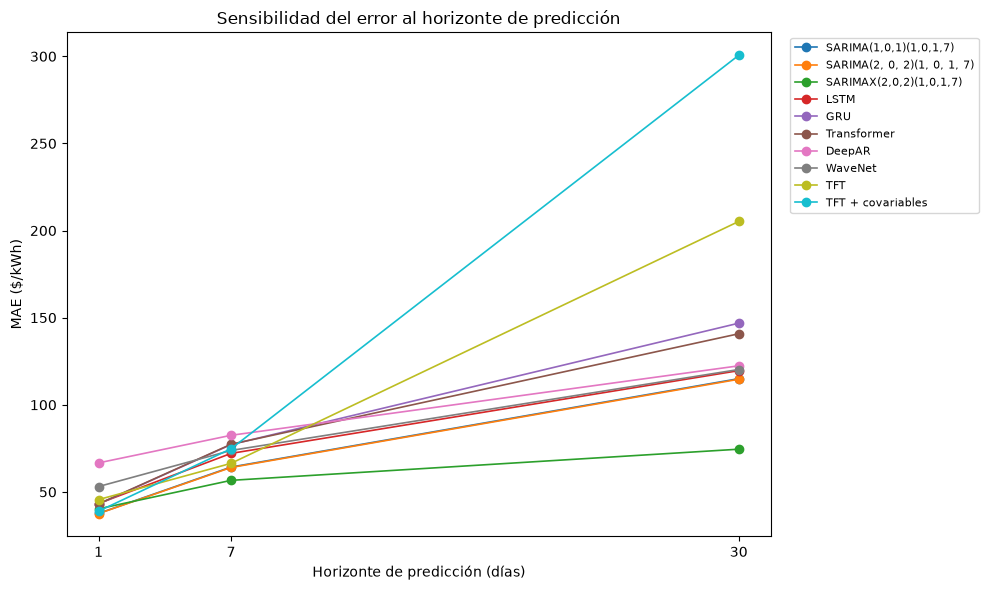

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for modelo in tabla['Modelo'].unique():
    sub = tabla[tabla['Modelo'] == modelo].sort_values('Horizonte')
    if len(sub) > 1:  # solo modelos con más de un horizonte aportan a la curva de sensibilidad
        ax.plot(sub['Horizonte'], sub['MAE'], marker='o', label=modelo, linewidth=1.2)

ax.set_xlabel('Horizonte de predicción (días)')
ax.set_ylabel('MAE ($/kWh)')
ax.set_xticks([1, 7, 30])
ax.set_title('Sensibilidad del error al horizonte de predicción')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
# Mejor modelo por horizonte, según MAE
for h in [1, 7, 30]:
    sub = tabla[tabla['Horizonte'] == h]
    if not sub.empty:
        mejor = sub.loc[sub['MAE'].idxmin()]
        print(f"Horizonte {h}d — mejor modelo: {mejor['Modelo']} (MAE={mejor['MAE']}, RMSE={mejor['RMSE']}, MAPE={mejor['MAPE (%)']}%)")

Horizonte 1d — mejor modelo: SARIMA(2, 0, 2)(1, 0, 1, 7) (MAE=37.58, RMSE=54.2, MAPE=12.97%)
Horizonte 7d — mejor modelo: SARIMAX(2,0,2)(1,0,1,7) (MAE=56.65, RMSE=79.27, MAPE=19.23%)
Horizonte 30d — mejor modelo: SARIMAX(2,0,2)(1,0,1,7) (MAE=74.53, RMSE=105.0, MAPE=26.72%)


In [8]:
tabla_ordenada = tabla.sort_values(['Horizonte', 'MAE'], ascending=[True, True])

for h in [1, 7, 30]:
    print(f"\n{'='*70}\nHorizonte: {h} día(s) — ordenado de mejor a peor (MAE)\n{'='*70}")
    vista = tabla_ordenada[tabla_ordenada['Horizonte'] == h].set_index('Modelo')
    vista = vista.drop(columns='Horizonte')
    print(vista.to_string())


Horizonte: 1 día(s) — ordenado de mejor a peor (MAE)
                               MAE   RMSE  MAPE (%)  sMAPE (%)      R²  MedAE  MaxError  Sesgo
Modelo                                                                                        
SARIMA(2, 0, 2)(1, 0, 1, 7)  37.58  54.20     12.97      12.77  0.9344  26.23    277.91  -5.01
SARIMA(1,0,1)(1,0,1,7)       37.69  54.29     13.02      12.82  0.9342  26.82    276.52  -5.10
TFT + covariables            38.97  55.19     13.81      12.90  0.9320  27.60    246.77  10.90
SARIMAX(2,0,2)(1,0,1,7)      40.30  58.92     14.03      14.09  0.9225  26.23    332.33  -2.94
GRU                          43.05  62.06     13.77      14.06  0.9140  29.18    301.82 -16.13
Transformer                  43.15  61.40     14.44      14.54  0.9118  29.99    251.99  -9.57
LSTM                         43.36  59.65     15.69      15.04  0.9206  31.34    275.97   0.10
TFT                          45.61  65.02     14.88      13.85  0.9056  29.43    236.57  21

In [9]:
tabla_final_ordenada = tabla.sort_values(
    by=['Horizonte', 'MAE'],
    ascending=[True, True]
).reset_index(drop=True)

print(tabla_final_ordenada.to_string(index=False))

                                      Modelo  Horizonte    MAE   RMSE  MAPE (%)  sMAPE (%)      R²  MedAE  MaxError   Sesgo
                 SARIMA(2, 0, 2)(1, 0, 1, 7)          1  37.58  54.20     12.97      12.77  0.9344  26.23    277.91   -5.01
                      SARIMA(1,0,1)(1,0,1,7)          1  37.69  54.29     13.02      12.82  0.9342  26.82    276.52   -5.10
                           TFT + covariables          1  38.97  55.19     13.81      12.90  0.9320  27.60    246.77   10.90
                     SARIMAX(2,0,2)(1,0,1,7)          1  40.30  58.92     14.03      14.09  0.9225  26.23    332.33   -2.94
                                         GRU          1  43.05  62.06     13.77      14.06  0.9140  29.18    301.82  -16.13
                                 Transformer          1  43.15  61.40     14.44      14.54  0.9118  29.99    251.99   -9.57
                                        LSTM          1  43.36  59.65     15.69      15.04  0.9206  31.34    275.97    0.10
        